# Multiple Linear Regression Energy Used

Tutorial 7: Winter 2026 IBEHS 3S03

A hospital’s central sterile processing tracks the electrical energy used each month to run sterilizers, washers, ventilation, and supporting equipment. The hospital is interested in better understanding and being able to predict energy use. You suspect monthly electricity use is related to operational and quality factors

  
* y  =  monthly  electrical  energy  used  (e.g.,  in  MWh)
* x1  =  average  ambient  temperature  in  the  facility  area  that  month  (°C)
* x2  =  number  of  operating  days  in  the  month  (days)
* x3  =  average  sterilization  quality  score  for  that  month  (%,  higher  is  better)
* x4  =  number  of  instrument  trays  processed  that  month  (in  hundreds  of  trays)
  
The  past  year’s  historical  data  are  provided  in  the  energyuse.csv  file.

We previously found that the environmental condition Number of Days affects monthly Energy use. However, energy consumption in a hospital may also depend on operational activity.

Therefore, we will extend the Simple Linear Regression (SLR) model to a Multiple Linear Regression (MLR) model by including additional predictors and account for multiple contributing factors. 

## Part 1:
### a. Read in data and create a correlation matrix 

### b. Fit the SLR for the model that has the highest correaltion betwen EnergyUse and a predictor variable and name it `model1`. 

In [3]:
%reset
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols
import statsmodels.api as sm
import scipy.stats as stats
%matplotlib inline

Once deleted, variables cannot be recovered. Proceed (y/[n])?  y


In [5]:
energy=pd.read_csv('EnergyUse.csv')
energy

,EnergyUse,Temp,NoDays,QAScore,TrayNumber
0,240,25,24,91,100
1,236,31,21,90,95
2,270,45,24,88,110
3,274,60,25,87,88
4,301,65,25,91,94
5,316,72,26,94,99
6,300,80,25,87,97
7,296,84,25,86,96
8,267,75,24,88,110
9,276,60,25,91,105


In [6]:
corr_matrix = energy.corr()
print(corr_matrix)

            EnergyUse      Temp    NoDays   QAScore  TrayNumber
EnergyUse    1.000000  0.802538  0.826963  0.092851   -0.132660
Temp         0.802538  1.000000  0.660456 -0.287566   -0.023559
NoDays       0.826963  0.660456  1.000000  0.112739   -0.025328
QAScore      0.092851 -0.287566  0.112739  1.000000    0.078914
TrayNumber  -0.132660 -0.023559 -0.025328  0.078914    1.000000


In [11]:
model1 = ols('EnergyUse ~ NoDays', data=energy).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:              EnergyUse   R-squared:                       0.684
Model:                            OLS   Adj. R-squared:                  0.652
Method:                 Least Squares   F-statistic:                     21.63
Date:                Fri, 13 Mar 2026   Prob (F-statistic):           0.000907
Time:                        13:37:32   Log-Likelihood:                -47.953
No. Observations:                  12   AIC:                             99.91
Df Residuals:                      10   BIC:                             100.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -100.5179     81.293     -1.236      0.2

## Part 2:  

### a. Fit a OLS MLR model with the top 2 predictors and produce the summary output and ANOVA table for model2

In [9]:
model2 = ols('EnergyUse ~ NoDays + Temp', data=energy).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:              EnergyUse   R-squared:                       0.800
Model:                            OLS   Adj. R-squared:                  0.756
Method:                 Least Squares   F-statistic:                     18.05
Date:                Fri, 13 Mar 2026   Prob (F-statistic):           0.000708
Time:                        13:37:08   Log-Likelihood:                -45.192
No. Observations:                  12   AIC:                             96.38
Df Residuals:                       9   BIC:                             97.84
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.9164     81.913      0.048      0.9

In [12]:
anova_table = sm.stats.anova_lm(model2, typ=2)
print(anova_table)

               sum_sq   df         F    PR(>F)
NoDays    1027.823217  1.0  7.052294  0.026234
Temp       766.222718  1.0  5.257351  0.047549
Residual  1311.687996  9.0       NaN       NaN


### b. Results attributes for ols model fit

https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLSResults.html

Use the attributes or basic formulas for the fitted model to **find** and **interpret**:

* SS_Residuals
* MSE
* the F-statistic and the p-value
* R-squared adjusted

In [14]:
ssresidual =  model2.ssr
print(f"{ssresidual}")

1311.6879964526797


In [18]:
mse = model2.mse_resid
print(f"{mse}")

145.74311071696442


In [20]:
fStatis = model2.fvalue
print(f"{fStatis}")
fVal = model2.f_pvalue
print(f"{fVal}")

18.049665072784748
0.0007084772043584015


In [21]:
rSqrAdj = model2.rsquared_adj
print(f"{rSqrAdj}")

0.7560939383246998


## Part 3:  Assumptions Review for Multiple Linear Regression

Create a Residual versus Fitted plot and a Residual QQ-plot for a resiudal review of the MLR Model and interpret the results.  

Text(0.5, 1.0, 'Residual vs Fitted Plot')

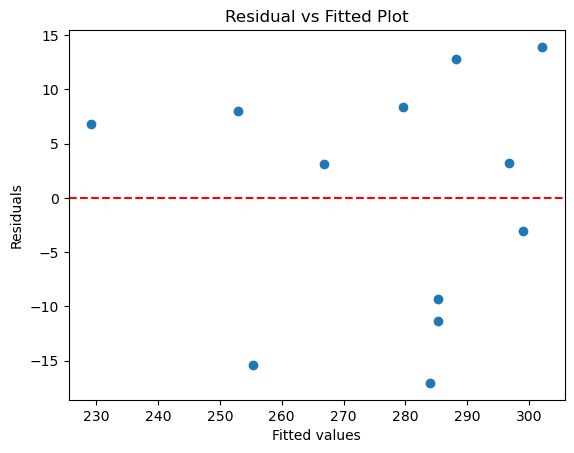

In [22]:
plt.scatter(model2.fittedvalues, model2.resid)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residual vs Fitted Plot')

Text(0.5, 1.0, 'Residual QQ-plot')

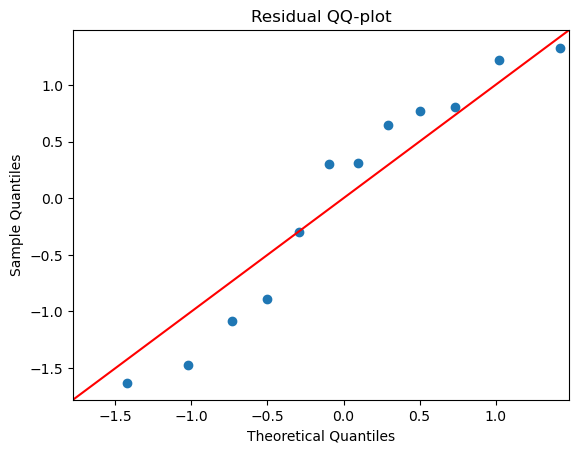

In [23]:
sm.qqplot(model2.resid, line='45', fit=True)
plt.title('Residual QQ-plot')

For the residual vs fitted plot, it is non-linear and therefore this suggests that the relationship between the predictors ( which are the NoDays and Temp) with EnergyUse is sufficiently linear. For the residual QQ plotof the MLR model, the plot follow a linear model and therefore the residuals are approximately normally ddistrubtued.

## Step 4:  View the surface response for the Fitted Model

Fill in the Predictor Variables Below and Run to see the best fitting surface

In [27]:
#%matplotlib widget  #  this would enable movemnet but can be glitchy
from mpl_toolkits.mplot3d import Axes3D

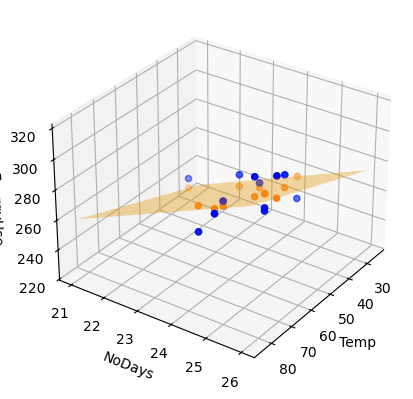

In [30]:
# provided code

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Control view with elev (vertical tilt) adn azim (horixontal rotation angle)
ax.view_init(elev=30, azim=35)

# observed data  # add Predictor Variable Names
xSP = energy['Temp']
ySP = energy['NoDays']
zSP = energy['EnergyUse']

ax.scatter(xSP, ySP, zSP)

ax.set_xlabel("Temp")
ax.set_ylabel("NoDays")
ax.set_zlabel("EnergyUse")

# fitted values
ax.scatter(xSP.values, ySP.values, model2.fittedvalues.values)

# create prediction grid
x_surf = np.linspace(energy['Temp'].min(), energy['Temp'].max(), 30)
y_surf = np.linspace(energy['NoDays'].min(), energy['NoDays'].max(), 30)

x_surf, y_surf = np.meshgrid(x_surf, y_surf)

# dataframe for prediction
exog = pd.DataFrame({
    "Temp": x_surf.ravel(),
    "NoDays": y_surf.ravel()
})

z_surf = model2.predict(exog=exog).values.reshape(x_surf.shape)

# regression surface
ax.plot_surface(x_surf, y_surf, z_surf, alpha=0.4, color='orange')

ax.scatter(xSP, ySP, zSP, color='blue', label="Observed")

plt.show()

## Step 5: Find the best model Forward Step Selction

In this last step we will determine the best regression model using forward selection. Forward selection begins with no predictors and adds predictors one at a time, selecting the variable that provides the greatest improvement in the model.

We will evaluate models using Adjusted $R^2$.  Recall that $R^2$ always increases when predictors are added, so we will use Adjusted $R^2$ to penalize for adding predictors that don't actually improve the model.  Penalizing unnecessary predictors is therefore better for comparing models with different numbers of variables.  (AIC (Akaike Information Criterion) and BIC AIC stands for Akaike Information Criterion are also goodness of fit criteria used to compare statistical models and choose the one that provides the best balance between goodness-of-fit and model complexity, but we will use $R^2$).  

Fit the regression model using each predcitor individually.  Record the Adjusted $R^2$ and choose the highest variance explained.  Next, adding each remaining predictor to the model to fit a two-predictor model.  Record the Adjusted $R^2$ and choose the highest variance explained.  Continue adding in a forward-wise manner each individual predictor until all predictors have been evaluated and no further improvemnet in $R^2$ is found.  Select this final model as the best fitting model. 

Forward selection allows us to build a regression model systematically by adding predictors that improve model performance while avoiding unnecessary complexity.

### Provide a table that shows the predcitors for the model and the Adjusted $R^2$ values

### Questions

* What is the final selected model?
* Write the fitted regression equation for the selected model.
* Interpret the model to explain how the selected predictors predict hospital electrical energy use.

In [31]:
# Code for foward selection best fit

import numpy as np
from statsmodels.formula.api import ols

# -----------------------------
# SETTINGS (change these for your y response and your predictors)
# -----------------------------
response = "EnergyUse"
candidate_vars = [
    "NoDays","Temp","QAScore","TrayNumber"
]

min_k, max_k = 1, 4 #choose how many variables to use
criterion = "adj_r2"   # ✅ choices: "mse", "aic", "bic", "adj_r2", "r2"

data=energy
# -----------------------------

def score_model(fit, criterion: str):
    """Return (score, direction) where direction is 'min' or 'max'."""
    criterion = criterion.lower()

    if criterion == "mse":
        # training MSE on rows actually used by statsmodels
        y_used = fit.model.endog
        yhat_used = fit.fittedvalues
        mse = np.mean((y_used - yhat_used) ** 2)
        return mse, "min"

    if criterion == "aic":
        return fit.aic, "min"

    if criterion == "bic":
        return fit.bic, "min"

    if criterion == "r2":
        return fit.rsquared, "max"

    if criterion == "adj_r2":
        return fit.rsquared_adj, "max"

    raise ValueError(f"Unknown criterion: {criterion}")


# -----------------------------
# FORWARD SELECTION (train only)
# -----------------------------
selected = []
remaining = list(candidate_vars)   # keep order
step_history_verbose = []
data_for_selection = data    # training data only

for step in range(1, max_k + 1):
    candidates = []
    print(f"\n Step {step}: Evaluating all remaining variables...")
    print(f"   Current predictors: {selected}")
    print(f"   Remaining candidates: {remaining}\n")

    for candidate in remaining:
        predictors = selected + [candidate]
        formula = f"{response} ~ {' + '.join(predictors)}"
        print("Trying formula:", formula)

        try:
            fit = ols(formula, data=data_for_selection).fit()
            score, direction = score_model(fit, criterion)

            # also show some common stats (optional)
            print(f"    • {criterion.upper()}: {score:.4f} | R²: {fit.rsquared:.4f} | Adj R²: {fit.rsquared_adj:.4f} | AIC: {fit.aic:.2f}")

            candidates.append((score, candidate, fit))
        except Exception as e:
            print(f"    • Error fitting model with {candidate}: {e}")

    if not candidates:
        print(" No valid models could be fit this step.")
        break

    # pick best at this step (add-only)
    if direction == "min":
        best_score, best_candidate, best_model = min(candidates, key=lambda x: x[0])
    else:
        best_score, best_candidate, best_model = max(candidates, key=lambda x: x[0])

    print(f"\n Best candidate to add: {best_candidate}")
    print(f"   Best {criterion.upper()} at this step: {best_score:.4f}")
    print(best_model.summary2())

    selected.append(best_candidate)
    remaining.remove(best_candidate)

    step_history_verbose.append({
        "step": step,
        "added": best_candidate,
        "criterion": criterion,
        "score": best_score,
        "model": best_model,
        "selected_set": selected.copy()
    })

# -----------------------------
# choose best size among min_k..max_k
# -----------------------------
if step_history_verbose:
    slice_hist = step_history_verbose[min_k-1:max_k]

    if direction == "min":
        best_entry = min(slice_hist, key=lambda d: d["score"])
    else:
        best_entry = max(slice_hist, key=lambda d: d["score"])

    final_model = best_entry["model"]

    print(f"\n Best model among sizes {min_k}..{max_k} (TRAINING DATA):")
    print(f"    Criterion: {criterion}")
    print(f"    Predictors: {best_entry['selected_set']}")
    print(f"    Best {criterion.upper()}: {best_entry['score']:.4f}")
    print(final_model.summary2())
else:
    print(" No predictors improved the model.")



 Step 1: Evaluating all remaining variables...
   Current predictors: []
   Remaining candidates: ['NoDays', 'Temp', 'QAScore', 'TrayNumber']

Trying formula: EnergyUse ~ NoDays
    • ADJ_R2: 0.6523 | R²: 0.6839 | Adj R²: 0.6523 | AIC: 99.91
Trying formula: EnergyUse ~ Temp
    • ADJ_R2: 0.6085 | R²: 0.6441 | Adj R²: 0.6085 | AIC: 101.33
Trying formula: EnergyUse ~ QAScore
    • ADJ_R2: -0.0905 | R²: 0.0086 | Adj R²: -0.0905 | AIC: 113.62
Trying formula: EnergyUse ~ TrayNumber
    • ADJ_R2: -0.0806 | R²: 0.0176 | Adj R²: -0.0806 | AIC: 113.51

 Best candidate to add: NoDays
   Best ADJ_R2 at this step: 0.6523
                 Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.652   
Dependent Variable: EnergyUse        AIC:                99.9051 
Date:               2026-03-13 14:27 BIC:                100.8749
No. Observations:   12               Log-Likelihood:     -47.953 
Df Model:           1                F-statistic:        21.63   
Df 

1. The final selected model uses three predictors: NoDays, Temp, and the QAScore.
2. EnergyUse = -162.1350 + 7.6906(NoDays) + 0.7487(Temp) + 2.3434(QAScore).
3. Energyuse will be -162 for all the other predictors being zero. 7.6906 mwh for every additional operating days. 0.7487 mwh for every increase in degree celcius. 2.3434 mwh for every percent of sterlization quality score.